# IFT learning curves from JSONL results

This notebook reads the per-epoch JSONL logs written by `interactiondynamics.train --save-jsonl` and plots training, validation, and test loss over epochs. Edit the configuration cell, then use **Run All**.

In [ ]:
from __future__ import annotations

import json
import os
from pathlib import Path

# Keep Matplotlib's cache inside the project instead of an unavailable home directory.
os.environ.setdefault("MPLCONFIGDIR", str(Path("..") / ".matplotlib"))

import matplotlib.pyplot as plt
from matplotlib import font_manager
import pandas as pd

# Register newly installed fonts explicitly, including fonts in ~/.local/share/fonts.
font_manager.fontManager = font_manager._load_fontmanager(try_read_cache=False)
font_paths = []
for root in (Path.home() / ".local" / "share" / "fonts", Path("/usr/local/share/fonts"), Path("/usr/share/fonts")):
    if root.exists():
        font_paths.extend(root.rglob("*.ttf"))
        font_paths.extend(root.rglob("*.otf"))
for path in font_paths:
    if any(token in path.name.lower().replace("-", " ") for token in ("source sans", "sourcesans")):
        font_manager.fontManager.addfont(str(path))

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
PAPER_FONT = next(
    (font for font in ("Source Sans 3", "Source Sans Pro", "Nimbus Sans", "Ubuntu Sans", "Liberation Sans", "DejaVu Sans") if font in available_fonts),
    "DejaVu Sans",
)
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [PAPER_FONT, "Source Sans 3", "Source Sans Pro", "Nimbus Sans", "Ubuntu Sans", "Liberation Sans", "DejaVu Sans"],
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.7,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "savefig.dpi": 600,
    }
)
print(f"Publication font: {PAPER_FONT}")
print("Registered Source Sans files:", [str(path) for path in font_paths if "source sans" in path.name.lower() or "sourcesans" in path.name.lower()])


Publication font: Liberation Sans


## Select result files

By default this selects first-order diffusion logs. Replace `JSONL_PATHS` with explicit paths when comparing a particular set of runs. `RUN_FILTER = None` plots every method contained in the selected files.

In [7]:
RESULTS_DIR = Path("..") / "derived" / "results"

# Example: choose all first-order diffusion result logs.
JSONL_PATHS = sorted(RESULTS_DIR.glob("first_order_diffusion*.jsonl"))
# JSONL_PATHS = [RESULTS_DIR / "my_experiment.jsonl"]

# Use None to include every method / seed in the selected files.
RUN_FILTER = {"ift1_generic"}
SEED_FILTER = None
LOG_Y = False

# The shaded halo shows one standard deviation across repeated seeds.
# Set to "sem" for the standard error of the mean instead.
UNCERTAINTY = "sem"

# At one selected method, the exported plot is exactly 6.5 × 3 inches.
PAPER_WIDTH_IN = 6.5
PAPER_HEIGHT_PER_PANEL_IN = 3.0
EXPORT_STEM = Path("..") / "derived" / "figures" / "ift1_generic_diffusion_learning_curves"

if not JSONL_PATHS:
    raise FileNotFoundError(f"No JSONL files matched under {RESULTS_DIR.resolve()}")

for path in JSONL_PATHS:
    print(path)


../derived/results/first_order_diffusion_generic_seed0.jsonl
../derived/results/first_order_diffusion_generic_seed1.jsonl
../derived/results/first_order_diffusion_generic_seed2.jsonl
../derived/results/first_order_diffusion_generic_seed2025.jsonl
../derived/results/first_order_diffusion_generic_seed2026.jsonl
../derived/results/first_order_diffusion_generic_seed3.jsonl
../derived/results/first_order_diffusion_generic_seed4.jsonl
../derived/results/first_order_diffusion_generic_seed42.jsonl
../derived/results/first_order_diffusion_generic_seed5.jsonl
../derived/results/first_order_diffusion_generic_seed6.jsonl


In [8]:
def value(record: dict, section: str, key: str):
    return record.get(section, {}).get(key, float("nan"))


def load_learning_curves(paths: list[Path]) -> pd.DataFrame:
    rows = []
    for path in paths:
        with path.open(encoding="utf-8") as handle:
            for line_number, line in enumerate(handle, start=1):
                if not line.strip():
                    continue
                record = json.loads(line)
                overrides = record.get("train_cfg_overrides", {})
                rows.append(
                    {
                        "source": path.name,
                        "line_number": line_number,
                        "run": record.get("run", "unknown"),
                        "seed": record.get("seed"),
                        "epoch": record.get("epoch"),
                        "learning_rate": record.get("effective_lr", overrides.get("lr")),
                        "train_loss": value(record, "train_step", "loss"),
                        "train_eval_loss": value(record, "train_eval", "loss"),
                        "val_loss": value(record, "val", "loss"),
                        "test_loss": value(record, "test", "loss"),
                        "val_edge_mse": value(record, "val", "edge_mse"),
                        "test_edge_mse": value(record, "test", "edge_mse"),
                        "val_rollout_r2": value(record, "rollout_val", "rollout_edge_r2"),
                        "test_rollout_r2": value(record, "rollout_test", "rollout_edge_r2"),
                    }
                )

    frame = pd.DataFrame(rows)
    if frame.empty:
        raise ValueError("The selected JSONL files did not contain epoch records.")

    # If a run was appended or re-run in a single file, keep its latest record for each epoch.
    return (
        frame.sort_values("line_number")
        .drop_duplicates(["source", "run", "seed", "epoch"], keep="last")
        .sort_values(["source", "run", "seed", "epoch"])
        .reset_index(drop=True)
    )


curves = load_learning_curves(JSONL_PATHS)
if RUN_FILTER is not None:
    curves = curves[curves["run"].isin(RUN_FILTER)]
if SEED_FILTER is not None:
    curves = curves[curves["seed"].isin(SEED_FILTER)]

if curves.empty:
    raise ValueError("The run/seed filters removed every record.")

curves[["source", "run", "seed", "learning_rate", "epoch"]].groupby(
    ["run", "learning_rate"], dropna=False
).agg(
    first_epoch=("epoch", "min"),
    last_epoch=("epoch", "max"),
    seeds=("seed", "nunique"),
    files=("source", "nunique"),
)


,,first_epoch,last_epoch,seeds,files
run,learning_rate,,,,
ift1_generic,NaN,1,50,10,10


## Loss curves

Each panel is one method (and learning rate), aggregated across repeated seeds. Training loss is the optimization-time value; validation and test loss are the corresponding full evaluation passes recorded after that epoch. The translucent halo is ± one standard deviation by default.

Saved ../derived/figures/ift1_generic_diffusion_learning_curves.pdf and ../derived/figures/ift1_generic_diffusion_learning_curves.png


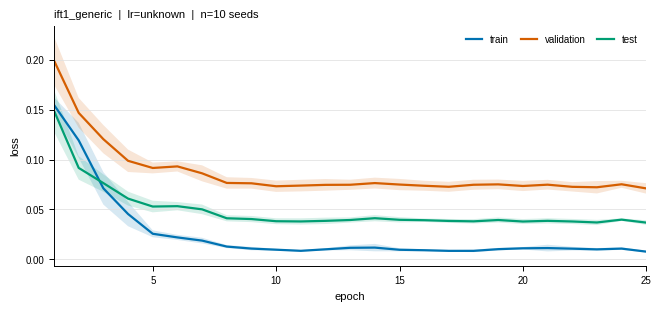

In [9]:
metric_columns = ["train_loss", "val_loss", "test_loss", "val_rollout_r2", "test_rollout_r2"]
group_columns = ["run", "learning_rate"]
summary = (
    curves.groupby(group_columns + ["epoch"], dropna=False, sort=False)
    .agg(
        **{f"{metric}_mean": (metric, "mean") for metric in metric_columns},
        **{f"{metric}_std": (metric, "std") for metric in metric_columns},
        replicates=("seed", "nunique"),
    )
    .reset_index()
    .sort_values(group_columns + ["epoch"])
)

for metric in metric_columns:
    spread = summary[f"{metric}_std"].fillna(0.0)
    if UNCERTAINTY == "std":
        summary[f"{metric}_error"] = spread
    elif UNCERTAINTY == "sem":
        summary[f"{metric}_error"] = spread / summary["replicates"].clip(lower=1).pow(0.5)
    else:
        raise ValueError("UNCERTAINTY must be either 'std' or 'sem'.")

groups = list(summary.groupby(group_columns, dropna=False, sort=False))
fig, axes = plt.subplots(
    nrows=len(groups),
    ncols=1,
    figsize=(PAPER_WIDTH_IN, PAPER_HEIGHT_PER_PANEL_IN * len(groups)),
    sharex=True,
    constrained_layout=True,
)
if len(groups) == 1:
    axes = [axes]

for axis, (identity, frame) in zip(axes, groups):
    run, learning_rate = identity
    for metric, label, color in (
        ("train_loss", "train", "#0072B2"),
        ("val_loss", "validation", "#D55E00"),
        ("test_loss", "test", "#009E73"),
    ):
        mean = frame[f"{metric}_mean"]
        error = frame[f"{metric}_error"]
        axis.plot(frame["epoch"], mean, label=label, color=color, linewidth=1.6)
        axis.fill_between(
            frame["epoch"],
            mean - error,
            mean + error,
            color=color,
            alpha=0.16,
            linewidth=0,
        )
    if LOG_Y:
        axis.set_yscale("log")
    lr_label = "unknown" if pd.isna(learning_rate) else f"{learning_rate:g}"
    n_seeds = int(frame["replicates"].max())
    axis.set_title(f"{run}  |  lr={lr_label}  |  n={n_seeds} seeds", loc="left")
    axis.set_ylabel("loss")
    axis.grid(axis="y", color="0.88", linewidth=0.55)
    axis.grid(axis="x", visible=False)
    axis.spines[["top", "right"]].set_visible(False)
    axis.legend(frameon=False, ncol=3, loc="best", handlelength=1.7, columnspacing=1.2)
    axis.set_xlim(1,   25)

axes[-1].set_xlabel("epoch")
EXPORT_STEM.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(EXPORT_STEM.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(EXPORT_STEM.with_suffix(".png"), dpi=600, bbox_inches="tight")
print(f"Saved {EXPORT_STEM.with_suffix('.pdf')} and {EXPORT_STEM.with_suffix('.png')}")
plt.show()


## Optional: rollout quality

This is not a loss curve, but it is useful for checking whether a lower one-step loss translates into better multi-step prediction.

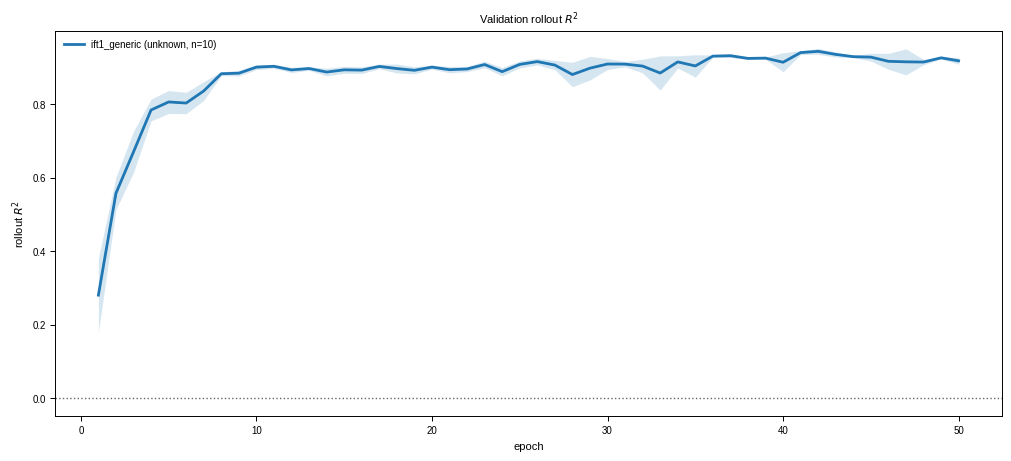

In [10]:
fig, axis = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
for identity, frame in groups:
    run, learning_rate = identity
    lr_label = "unknown" if pd.isna(learning_rate) else f"lr={learning_rate:g}"
    label = f"{run} ({lr_label}, n={int(frame['replicates'].max())})"
    mean = frame["val_rollout_r2_mean"]
    error = frame["val_rollout_r2_error"]
    line = axis.plot(frame["epoch"], mean, linewidth=2, label=label)[0]
    axis.fill_between(
        frame["epoch"],
        mean - error,
        mean + error,
        color=line.get_color(),
        alpha=0.18,
        linewidth=0,
    )

axis.axhline(0, color="0.4", linewidth=1, linestyle=":")
axis.set(title="Validation rollout $R^2$", xlabel="epoch", ylabel="rollout $R^2$")
axis.legend(frameon=False, loc="best")
plt.show()
